# Weather - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.


## About this data source

**Open-Meteo.** A free weather service built for programs rather than people: give it a
latitude, longitude and date range, and it returns decades of daily weather. No account, no
key, no cost. Think of it as: *"the weather history of any point on Earth, as a table."*

- **Explore it in a browser:** <https://open-meteo.com/en/docs/historical-weather-api>
  (a live form: type a city, tick *temperature* and *dew point*, and it builds the exact web
  address that returns the data)
- Research-grade source behind it (ERA5): <https://cds.climate.copernicus.eu/>

> Why weather at all? **Absolute humidity** is the established driver of influenza
> seasonality (Shaman & Kohn 2009; Shaman et al. 2010, 2012). Weather does not count cases;
> it shifts the conditions for transmission.


## Step 1: pull the weather

> *Using the Open-Meteo historical archive API (free, no key), pull daily mean*
> *temperature and dew point for Atlanta (33.749, -84.388) from 2016 to now. Return a*
> *tidy DataFrame and report the date range.*


In [4]:
import os
import json
import urllib.request
import urllib.parse
import pandas as pd

UA = {'User-Agent': 'SISMID2026-course/1.0 (nhidinh@jhu.edu)'}
LAT, LON = 21.028511, 105.804817   # Ha Noi
START, END = '2016-01-01', '2026-07-21'

CACHE_PATHS = [
    '../data/openmeteo_hanoi_weather.csv',
    'data/openmeteo_hanoi_weather.csv',
    './openmeteo_hanoi_weather.csv',
]

def fetch(url, timeout=60):
    return urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=timeout).read()

def load_cache():
    for p in CACHE_PATHS:
        if os.path.exists(p):
            print(f'Using cached snapshot: {p}')
            return pd.read_csv(p, parse_dates=['date'])[['date', 'temp_c', 'dewpoint_c']]
    raise FileNotFoundError('Open-Meteo cache not found; check the data/ folder.')

def openmeteo_hanoi_weather():
    """Daily mean temperature and dew point for Hanoi from the Open-Meteo
    historical archive API. Tidy DataFrame(date, temp_c, dewpoint_c); falls back
    to the cache on any failure."""
    params = {
        'latitude': LAT, 'longitude': LON,
        'start_date': START, 'end_date': END,
        'daily': 'temperature_2m_mean,dew_point_2m_mean',
        'timezone': 'Asia/Bangkok',
    }
    url = 'https://archive-api.open-meteo.com/v1/archive?' + urllib.parse.urlencode(params)
    try:
        d = json.loads(fetch(url))['daily']
        return pd.DataFrame({
            'date': pd.to_datetime(d['time']),
            'temp_c': d['temperature_2m_mean'],
            'dewpoint_c': d['dew_point_2m_mean'],
        })
    except Exception as e:
        print(f'Open-Meteo live pull failed ({type(e).__name__}): {e}')
        return load_cache()

wx = openmeteo_hanoi_weather()
print(f"{len(wx)} days, {wx['date'].min().date()} to {wx['date'].max().date()}")
wx.head()


3855 days, 2016-01-01 to 2026-07-21


,date,temp_c,dewpoint_c
0,2016-01-01,17.0,12.0
1,2016-01-02,18.6,14.8
2,2016-01-03,18.9,16.0
3,2016-01-04,19.0,16.8
4,2016-01-05,21.1,18.0


## Step 2: compute absolute humidity

> *Compute absolute humidity in g/m^3 from temperature T and dew point Td:*
> *e = 6.112 * exp(17.67*Td/(Td+243.5)); AH = 216.7 * e / (T+273.15). Resample to weekly*
> *and plot it, then plot the mean AH by calendar month.*

**Your check:** does AH bottom out in winter? That is the Shaman result: low absolute
humidity precedes influenza season.


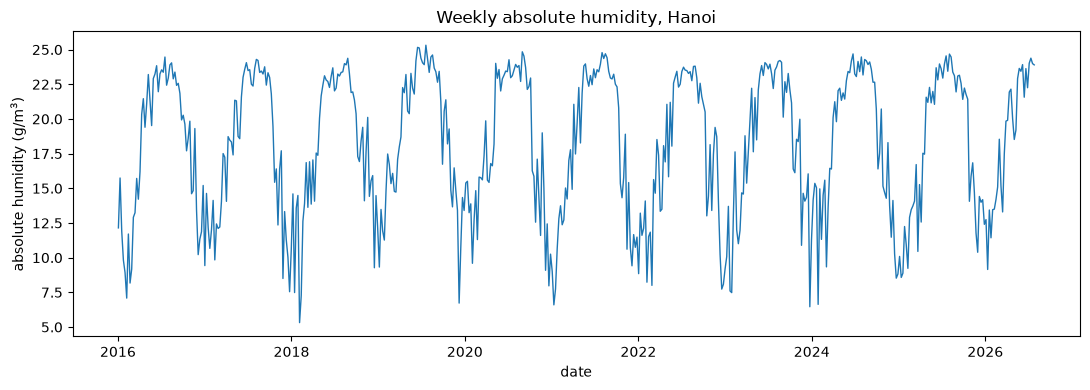

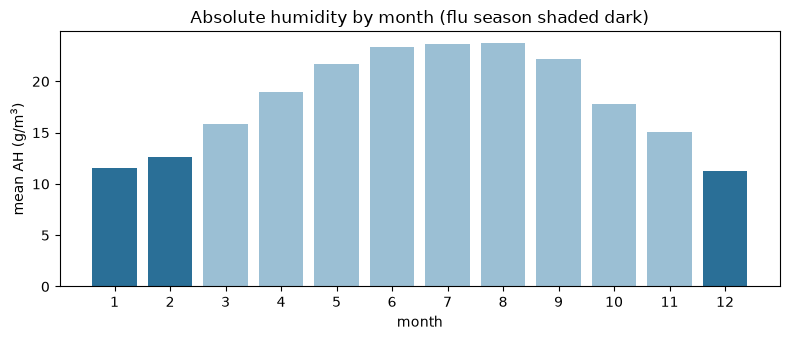

driest months: {12: 11.23, 1: 11.56, 2: 12.65}


In [5]:
import math
import matplotlib.pyplot as plt

def absolute_humidity(T, Td):
    """g/m^3 from temperature and dew point in Celsius."""
    if pd.isna(T) or pd.isna(Td):
        return float('nan')
    e = 6.112 * math.exp(17.67 * Td / (Td + 243.5))   # vapour pressure, hPa
    return 216.7 * e / (T + 273.15)

wx['abs_humidity_g_m3'] = [absolute_humidity(t, td) for t, td in zip(wx['temp_c'], wx['dewpoint_c'])]

wk = wx.set_index('date')['abs_humidity_g_m3'].resample('W').mean().reset_index()
plt.figure(figsize=(11, 4))
plt.plot(wk['date'], wk['abs_humidity_g_m3'], lw=1)
plt.ylabel('absolute humidity (g/m$^3$)'); plt.xlabel('date')
plt.title('Weekly absolute humidity, Hanoi')
plt.tight_layout(); plt.show()

wx['month'] = wx['date'].dt.month
monthly = wx.groupby('month')['abs_humidity_g_m3'].mean()
plt.figure(figsize=(8, 3.5))
plt.bar(monthly.index, monthly.values,
        color=['#2A6F97' if m in (12, 1, 2) else '#9bbfd4' for m in monthly.index])
plt.xticks(range(1, 13)); plt.xlabel('month'); plt.ylabel('mean AH (g/m$^3$)')
plt.title('Absolute humidity by month (flu season shaded dark)')
plt.tight_layout(); plt.show()
print('driest months:', monthly.nsmallest(3).round(2).to_dict())


## Step 3: sanity-check and save

> *Report the date range, missing values, and the AH range, then save a tidy CSV.*


In [3]:
print('date range :', wx['date'].min().date(), 'to', wx['date'].max().date())
print('missing    :')
print(wx[['temp_c', 'dewpoint_c', 'abs_humidity_g_m3']].isna().sum())
print('AH range   :', round(wx['abs_humidity_g_m3'].min(), 2), 'to',
      round(wx['abs_humidity_g_m3'].max(), 2), 'g/m^3')

wx.to_csv('weather_absolute_humidity.csv', index=False)
print('saved weather_absolute_humidity.csv:', wx.shape, '| file exists:', os.path.exists('weather_absolute_humidity.csv'))


date range : 2016-01-01 to 2026-07-21
missing    :
temp_c               0
dewpoint_c           0
abs_humidity_g_m3    0
dtype: int64
AH range   : 1.09 to 21.36 g/m^3
saved weather_absolute_humidity.csv: (3855, 5) | file exists: True


## Reflection

- Weather is a **modulator**, not a case count.
- **Stretch:** swap in a tropical city and compare the AH cycle.
